In [1]:
# Core libraries
import pandas as pd
import numpy as np


# Machine Learning
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN

# Statistics
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller

# Utilities
from itertools import combinations
import warnings

# Variables
import config as cfg

# Ignore warnings (useful for statistical tests)
warnings.filterwarnings("ignore")

In [57]:
import importlib
import core.analyse
import utils.io

importlib.reload(core.analyse)
importlib.reload(utils.io)

<module 'utils.io' from 'c:\\Users\\Asus\\Desktop\\Git\\master-projects\\financial-market-analysis\\src\\utils\\io.py'>

In [34]:
from utils.io import get_stock_data

prices = get_stock_data(cfg.TICKERS)

print("All data downloaded.")

[*********************100%***********************]  501 of 501 completed


-> Dados descarregados: 1508 dias, 501 ações.
-> Ações recentes/com falhas removidas: 15
-> DADOS FINAIS PARA O BOT: 1454 dias, 486 ações.
All data downloaded.


In [52]:
prices=prices.dropna()
prices.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-19,63.042412,59.145187,55.706898,66.955200,25.731314,145.760635,307.510010,81.280342,28.164461,103.926071,...,13.003693,45.176697,48.526409,26.257946,60.003880,40.000000,55.946522,82.418633,185.070007,97.001991
2020-03-20,63.713482,55.390331,53.950871,61.113476,24.694834,137.888657,295.339996,76.564751,25.765524,99.224281,...,11.891856,50.404305,42.367516,24.969078,55.749802,38.090000,51.906940,79.496925,179.380005,95.684372
2020-03-23,60.751175,54.213608,50.564224,56.458069,22.117901,132.140976,307.269989,76.636772,24.671263,96.576782,...,10.852528,55.835602,41.840332,23.985262,52.724461,40.009998,50.512730,74.716759,170.720001,87.835457
2020-03-24,64.231171,59.652611,52.908215,62.632324,24.343002,144.243271,310.000000,84.349037,27.204887,107.104881,...,13.599900,64.554771,45.229389,27.028225,57.713932,46.310001,62.256153,86.357430,180.550003,98.357521
2020-03-25,66.148514,59.323997,53.237473,63.584999,24.457109,139.617538,305.910004,84.915970,27.524748,108.548164,...,14.276672,72.798683,46.484600,28.439125,59.445366,52.389999,65.124969,89.528786,186.229996,102.575836


In [53]:
#Instead of using the prices, we will use the returns to avoid issues with different price scales. Each stock becomes a point in feature space.
returns = prices.pct_change().dropna()
returns.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-20,0.010645,-0.063485,-0.031523,-0.087248,-0.040281,-0.054006,-0.039576,-0.058016,-0.085176,-0.045242,...,-0.085502,0.115715,-0.126918,-0.049085,-0.070897,-0.047750,-0.072204,-0.035450,-0.030745,-0.013583
2020-03-23,-0.046494,-0.021244,-0.062773,-0.076176,-0.104351,-0.041683,0.040394,0.000941,-0.042470,-0.026682,...,-0.087398,0.107755,-0.012443,-0.039401,-0.054266,0.050407,-0.026860,-0.060130,-0.048277,-0.082029
2020-03-24,0.057283,0.100325,0.046357,0.109360,0.100602,0.091586,0.008885,0.100634,0.102695,0.109013,...,0.253155,0.156158,0.081000,0.126868,0.094633,0.157461,0.232484,0.155797,0.057580,0.119793
2020-03-25,0.029851,-0.005509,0.006223,0.015211,0.004687,-0.032069,-0.013194,0.006721,0.011757,0.013475,...,0.049763,0.127704,0.027752,0.052201,0.030000,0.131289,0.046081,0.036724,0.031459,0.042888
2020-03-26,0.068406,0.052623,0.087174,0.071519,0.153577,0.128573,0.054787,-0.018440,0.053823,0.118036,...,0.031603,-0.047296,0.042484,0.041030,0.064986,0.069479,0.039522,0.044104,0.060570,0.089640


Total de ações (N): 486 | Total de dias (T): 1453
Limite de Ruído Marchenko-Pastur (lambda_max): 2.4912
-> Componentes Principais Retidos (Sinal Puro): 16


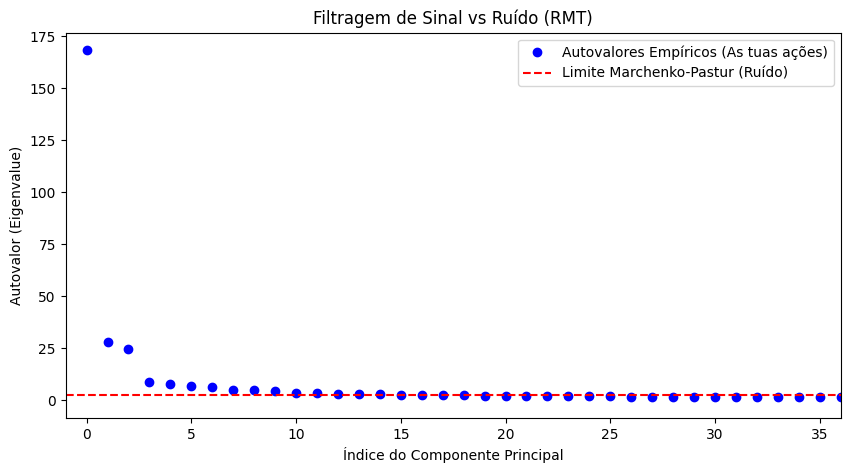

In [54]:
from core.analyse import calculate_RMT

X_pca = calculate_RMT(returns)

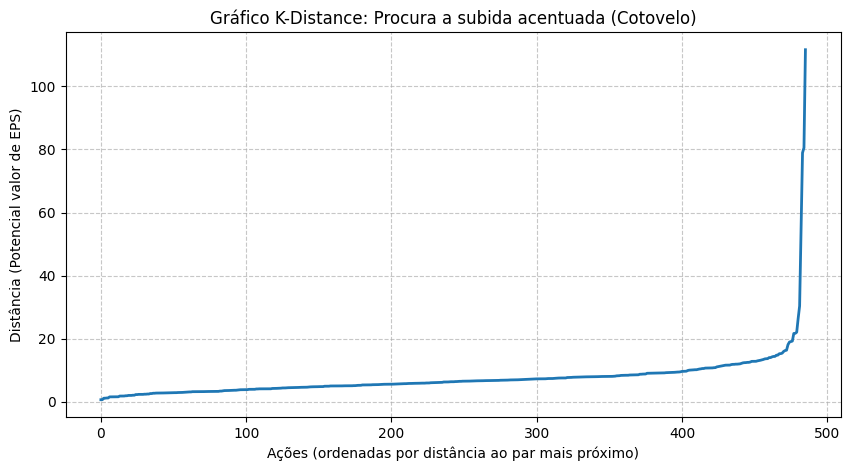

In [55]:
from core.analyse import calculate_nearest_neighbors

calculate_nearest_neighbors(X_pca)

Resumo do DBSCAN (eps=16.0):
-> 5 clusters estruturais encontrados.
-> 15 ações rejeitadas como ruído.

Possíveis Pares/Baskets encontrados:
Cluster 0: ['A', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APTV', 'ARE', 'ARES', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CDNS', 'CDW', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CIEN', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COO', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRH', 'CRL', 'CRM', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CTSH', 'CTVA', 'CVS', 'CVX', 'D', 'DAL', 'DD', 'DE', 

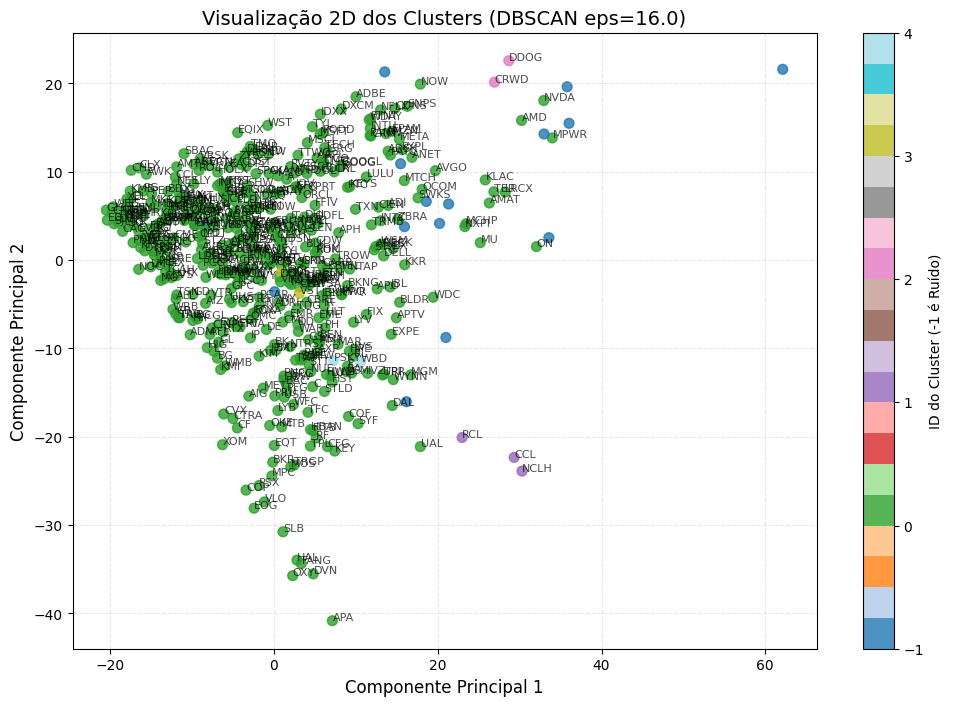

In [58]:
from core.analyse import RMT_clustering

pairs, clusters = RMT_clustering(16.0, X_pca, returns)

In [60]:
from itertools import combinations

# 1. Definir o tamanho máximo de um cluster aceitável
MAX_CLUSTER_SIZE = 15 

# 2. Extrair apenas os clusters que são "nichos" (entre 2 a 15 ações)
clusters_elite = [group for group in clusters.values() if 1 < len(group) <= MAX_CLUSTER_SIZE]

pairs = []

# 3. Gerar as combinações APENAS para os clusters de elite
for cluster in clusters_elite:
    for combo in combinations(cluster, 2):
        pairs.append(list(combo))

print(f"Total de pares candidatos a testar: {len(pairs)}\n")
print("Pares Candidatos:")
for p in pairs:
    print(p)

Total de pares candidatos a testar: 6

Pares Candidatos:
['CCL', 'NCLH']
['CCL', 'RCL']
['NCLH', 'RCL']
['CRWD', 'DDOG']
['NRG', 'VST']
['PSKY', 'WBD']


[*********************100%***********************]  2 of 2 completed


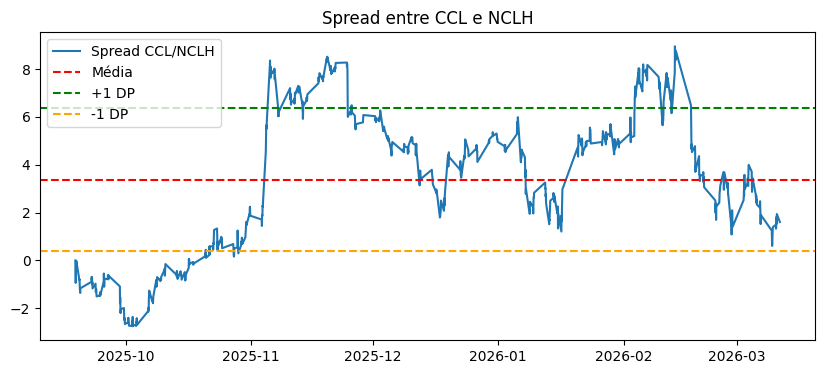

Par: CCL - NCLH | P-Valor ADF: 0.3629
NOT Stationary.



[*********************100%***********************]  2 of 2 completed


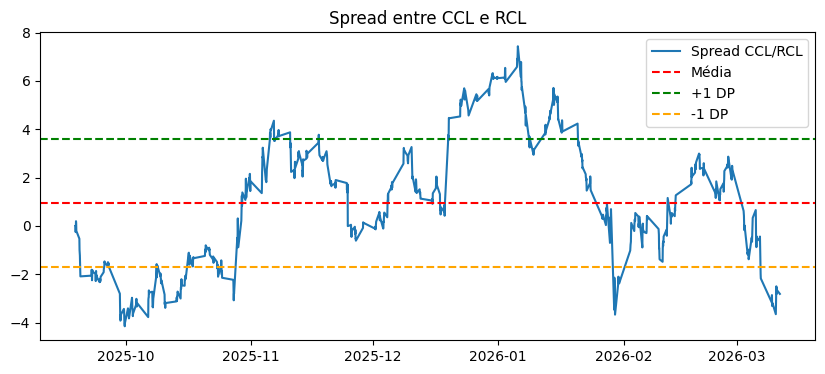

Par: CCL - RCL | P-Valor ADF: 0.3001
NOT Stationary.



[*********************100%***********************]  2 of 2 completed


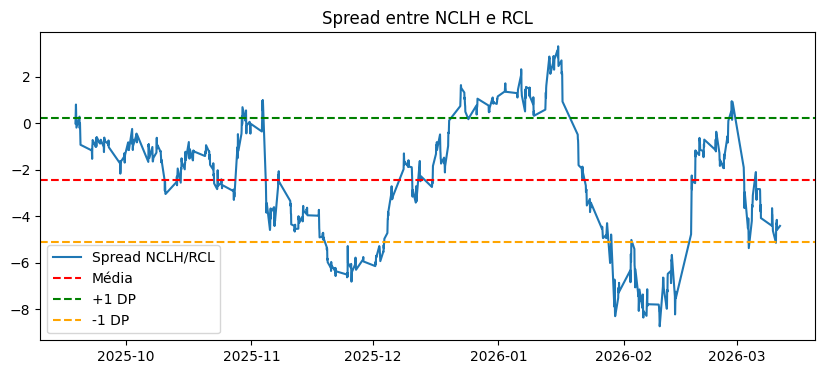

Par: NCLH - RCL | P-Valor ADF: 0.1714
NOT Stationary.



[*********************100%***********************]  2 of 2 completed


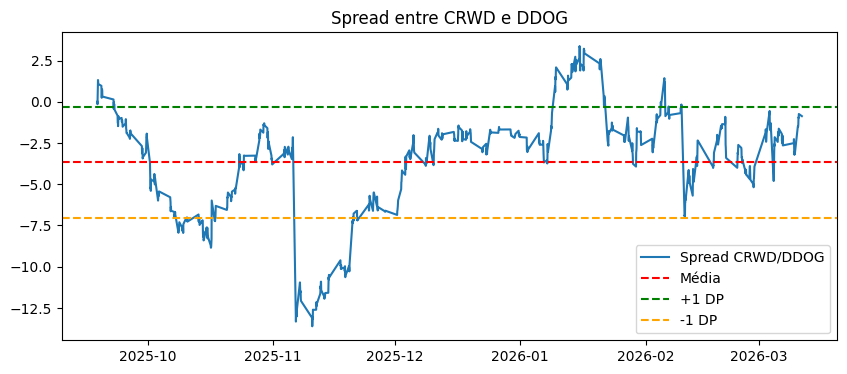

Par: CRWD - DDOG | P-Valor ADF: 0.0606
NOT Stationary.



[*********************100%***********************]  2 of 2 completed


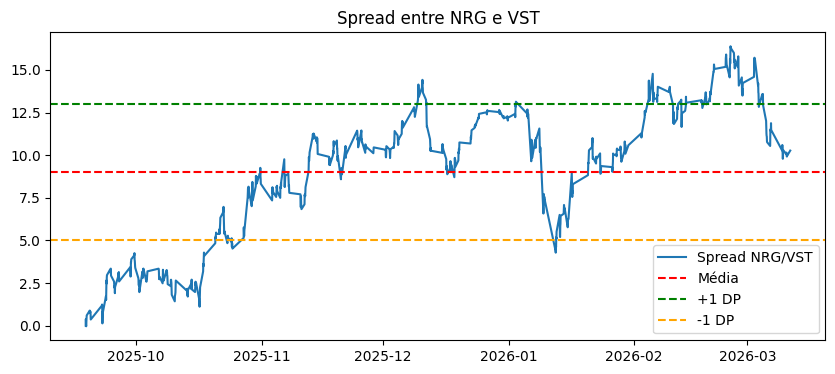

Par: NRG - VST | P-Valor ADF: 0.1739
NOT Stationary.



[*********************100%***********************]  2 of 2 completed


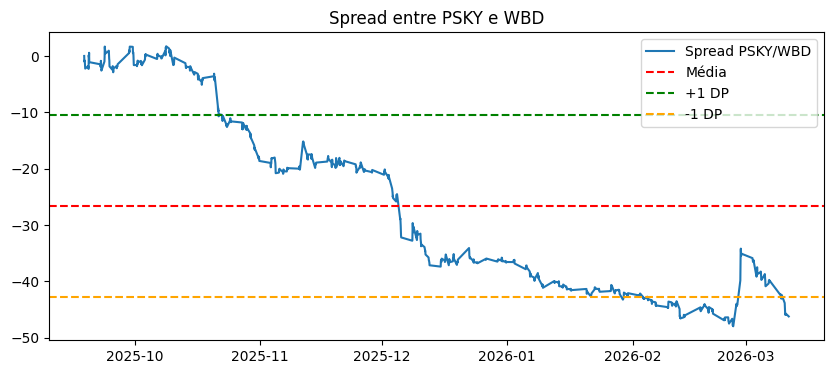

Par: PSKY - WBD | P-Valor ADF: 0.7368
NOT Stationary.



In [62]:
# Suggested pairs (by DBSCAN clustering)
#pairs = [['CDNS', 'SNPS'],
#['KO', 'PEP']]
import yfinance as yf

# Test pairs - spread stationarity 
def test_spread(pair):
    stock1, stock2 = pair

    #data = yf.download([stock1, stock2], start="2020-01-01", end="2025-01-01")['Close'].dropna()
    data = yf.download([stock1, stock2], period='120d', interval='1h' )['Close'].dropna()
    
    # Normalization and spread
    initial_scale = data[stock1].iloc[0] / data[stock2].iloc[0]
    stock2_scaled = data[stock2] * initial_scale

    spread = ((data[stock1] - stock2_scaled) / (data[stock1] + stock2_scaled)) * 100

    # Test Dickey-Fuller (ADF) - Stationarity
    adf_result = adfuller(spread)
    p_value = adf_result[1]  # P-value --> se p-value < 0.05 == Stationary

    # Plot spread
    plt.figure(figsize=(10, 4))
    plt.plot(spread, label=f'Spread {stock1}/{stock2}')
    plt.axhline(spread.mean(), color='red', linestyle='--', label='Média')
    plt.axhline(spread.mean() + spread.std(), color='green', linestyle='--', label='+1 DP')
    plt.axhline(spread.mean() - spread.std(), color='orange', linestyle='--', label='-1 DP')
    plt.legend()
    plt.title(f'Spread entre {stock1} e {stock2}')
    plt.show()

    
    print(f"Par: {stock1} - {stock2} | P-Valor ADF: {p_value:.4f}")
    if p_value < 0.05:
        print("Stationary.\n")
    else:
        print("NOT Stationary.\n")

for pair in pairs:
    test_spread(pair)